# Supply Chain Analysis: Transforming Data into Actionable Business Insights

**Dataset:** DataCo Supply Chain dataset (180,519 order line items, 53 features) including customer demographics, order and shipping details, product pricing, and order status.

**Business Problem:** A retail company operates across multiple products, warehouses, and regions, but is experiencing problems with delivery delays, order cancellations, and inconsistent shipping performance.

**Objective:** Analyze supply chain and order data to quantify delivery delays, shipping-mode performance, order cancellations, and regional/category sales trends, and use these insights to improve delivery efficiency and overall supply chain performance.

**Approach:** Load and validate the data, then analyze revenue, delivery performance, cancellations, and regional trends, closing with a summary of key findings.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 60)

## 1. Load and Inspect the Data

In [2]:
df = pd.read_csv("DataCoSupplyChainDataset.csv", encoding="latin1")
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,Customer Country,Customer Email,Customer Fname,Customer Id,Customer Lname,Customer Password,Customer Segment,Customer State,Customer Street,Customer Zipcode,Department Id,Department Name,Latitude,Longitude,Market,Order City,Order Country,Order Customer Id,order date (DateOrders),Order Id,Order Item Cardprod Id,Order Item Discount,Order Item Discount Rate,Order Item Id,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Cally,20755,Holloway,XXXXXXXXX,Consumer,PR,5365 Noble Nectar Island,725.0,2,Fitness,18.251453,-66.037056,Pacific Asia,Bekasi,Indonesia,20755,1/31/2018 22:56,77202,1360,13.110000,0.04,180517,327.75,0.29,1,327.75,314.640015,91.250000,Southeast Asia,Java Occidental,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Irene,19492,Luna,XXXXXXXXX,Consumer,PR,2679 Rustic Loop,725.0,2,Fitness,18.279451,-66.037064,Pacific Asia,Bikaner,India,19492,1/13/2018 12:27,75939,1360,16.389999,0.05,179254,327.75,-0.80,1,327.75,311.359985,-249.089996,South Asia,Rajastán,PENDING,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,EE. UU.,XXXXXXXXX,Gillian,19491,Maldonado,XXXXXXXXX,Consumer,CA,8510 Round Bear Gate,95125.0,2,Fitness,37.292233,-121.881279,Pacific Asia,Bikaner,India,19491,1/13/2018 12:06,75938,1360,18.030001,0.06,179253,327.75,-0.80,1,327.75,309.720001,-247.779999,South Asia,Rajastán,CLOSED,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,EE. UU.,XXXXXXXXX,Tana,19490,Tate,XXXXXXXXX,Home Office,CA,3200 Amber Bend,90027.0,2,Fitness,34.125946,-118.291016,Pacific Asia,Townsville,Australia,19490,1/13/2018 11:45,75937,1360,22.940001,0.07,179252,327.75,0.08,1,327.75,304.809998,22.860001,Oceania,Queensland,COMPLETE,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,Puerto Rico,XXXXXXXXX,Orli,19489,Hendricks,XXXXXXXXX,Corporate,PR,8671 Iron Anchor Corners,725.0,2,Fitness,18.253769,-66.037048,Pacific Asia,Townsville,Australia,19489,1/13/2018 11:24,75936,1360,29.500000,0.09,179251,327.75,0.45,1,327.75,298.250000,134.210007,Oceania,Queensland,PENDING_PAYMENT,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [3]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 180519, Columns: 53


<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

## 2. Data Quality Check

Before analyzing, check for missing values and duplicate records so results aren't skewed by data issues.

In [4]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

print(f"\nDuplicate rows: {df.duplicated().sum()}")

Columns with missing values:
Product Description    180519
Order Zipcode          155679
Customer Lname              8
Customer Zipcode            3
dtype: int64



Duplicate rows: 0


## 3. Revenue Overview

In [5]:
total_revenue = df["Sales"].sum()
print(f"Total Revenue: ${total_revenue:,.2f}")

top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .round(2)
      .sort_values(ascending=False)
      .head(10)
      .reset_index(name="Total_Revenue")
)
top_products

Total Revenue: $36,784,735.01


,Product Name,Total_Revenue
0,Field & Stream Sportsman 16 Gun Fire Safe,6929653.69
1,Perfect Fitness Perfect Rip Deck,4421143.14
2,Diamondback Women's Serene Classic Comfort Bi,4118425.57
3,Nike Men's Free 5.0+ Running Shoe,3667633.20
4,Nike Men's Dri-FIT Victory Golf Polo,3147800.00
5,Pelican Sunstream 100 Kayak,3099845.09
6,Nike Men's CJ Elite 2 TD Football Cleat,2891757.66
7,O'Brien Men's Neoprene Life Vest,2888993.91
8,Under Armour Girls' Toddler Spine Surge Runni,1269082.67
9,Dell Laptop,663000.00


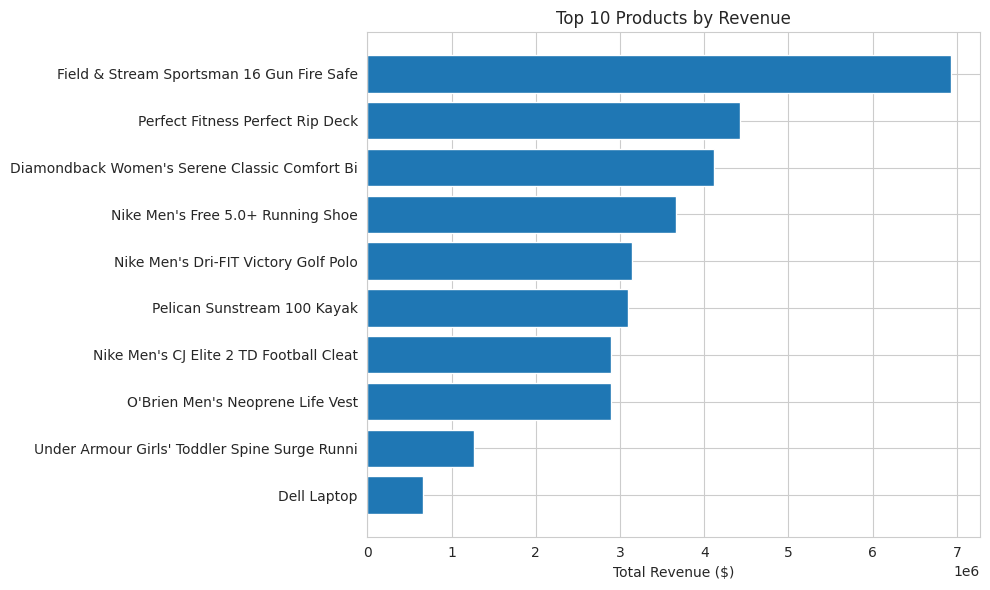

In [6]:
plt.figure(figsize=(10, 6))
plt.barh(top_products["Product Name"], top_products["Total_Revenue"])
plt.gca().invert_yaxis()
plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue ($)")
plt.tight_layout()
plt.show()

## 4. On-Time Delivery Rate

In [7]:
on_time_rate = (
    df.groupby("Shipping Mode")["Late_delivery_risk"]
      .apply(lambda x: (x == 0).mean() * 100)
      .reset_index(name="On_Time_Rate")
      .sort_values("On_Time_Rate", ascending=False)
)

on_time_rate

,Shipping Mode,On_Time_Rate
3,Standard Class,61.928317
1,Same Day,54.256958
2,Second Class,23.367219
0,First Class,4.677501


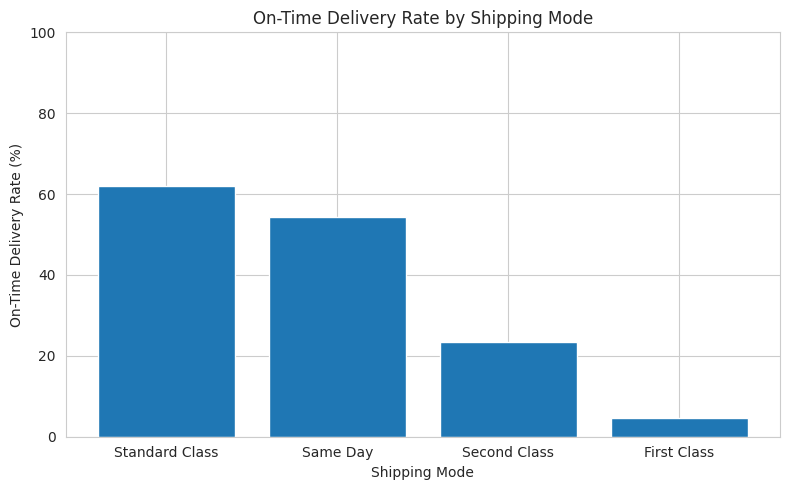

In [8]:
plt.figure(figsize=(8, 5))
plt.bar(on_time_rate["Shipping Mode"], on_time_rate["On_Time_Rate"])
plt.title("On-Time Delivery Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("On-Time Delivery Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## 5. Average Delivery Time

In [9]:
avg_delivery_time = (
    df.groupby("Shipping Mode")["Days for shipping (real)"]
      .mean()
      .round(2)
      .reset_index(name="Avg_Delivery_Time")
      .sort_values("Avg_Delivery_Time", ascending=False)
)

avg_delivery_time

,Shipping Mode,Avg_Delivery_Time
3,Standard Class,4.00
2,Second Class,3.99
0,First Class,2.00
1,Same Day,0.48


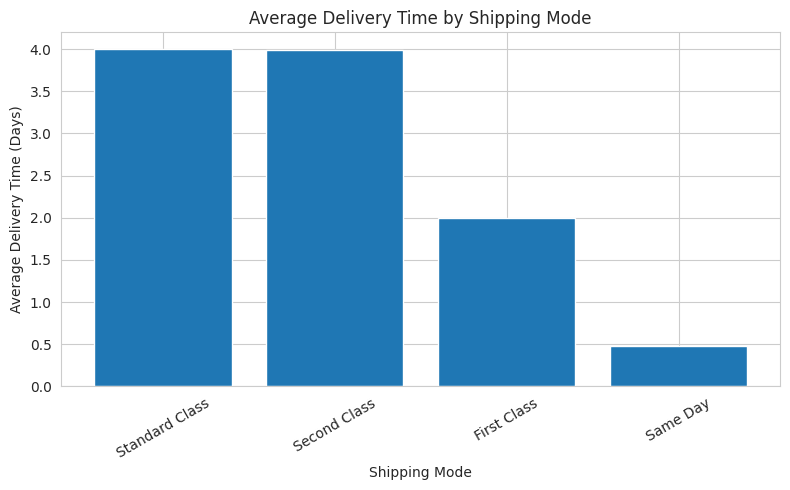

In [10]:
plt.figure(figsize=(8, 5))
plt.bar(avg_delivery_time["Shipping Mode"], avg_delivery_time["Avg_Delivery_Time"])
plt.title("Average Delivery Time by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Average Delivery Time (Days)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Cancellation Analysis

Note: this section measures orders with `Order Status == 'CANCELED'` specifically. The dataset's `Order Status` field also includes other terminal states (e.g. `SUSPECTED_FRAUD`, `ON_HOLD`), which are not counted here.

In [11]:
df["Order Status"].value_counts()

Order Status
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING         21902
PENDING            20227
CLOSED             19616
ON_HOLD             9804
SUSPECTED_FRAUD     4062
CANCELED            3692
PAYMENT_REVIEW      1893
Name: count, dtype: int64

In [12]:
cancellation_rate = (
    df.groupby("Shipping Mode")
      .agg(
          Total_Orders=("Order Id", "nunique"),
          Canceled_Orders=("Order Status", lambda x: (x == "CANCELED").sum())
      )
)

cancellation_rate["Cancellation_Rate"] = (
    cancellation_rate["Canceled_Orders"] / cancellation_rate["Total_Orders"] * 100
).round(2)

cancellation_rate = cancellation_rate.sort_values("Cancellation_Rate", ascending=False)
cancellation_rate

,Total_Orders,Canceled_Orders,Cancellation_Rate
Shipping Mode,,,
Same Day,3571,225,6.30
First Class,10079,615,6.10
Standard Class,39324,2191,5.57
Second Class,12778,661,5.17


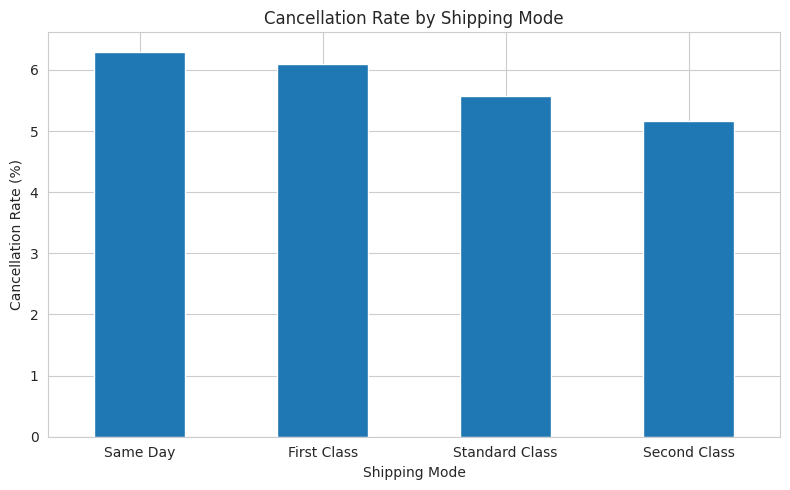

In [13]:
plt.figure(figsize=(8, 5))
cancellation_rate["Cancellation_Rate"].plot(kind="bar")
plt.title("Cancellation Rate by Shipping Mode")
plt.xlabel("Shipping Mode")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Regional Sales Trends

In [14]:
region_sales = (
    df.groupby("Order Region")["Sales"]
      .sum()
      .round(2)
      .sort_values(ascending=False)
      .reset_index(name="Total_Sales")
)

region_sales

,Order Region,Total_Sales
0,Western Europe,5894380.77
1,Central America,5665712.10
2,South America,2960881.41
3,Northern Europe,2155830.65
4,Southern Europe,2047918.82
5,Oceania,2016654.20
6,Southeast Asia,1932495.57
7,Caribbean,1651019.33
8,West of USA,1571415.96
9,South Asia,1553680.92


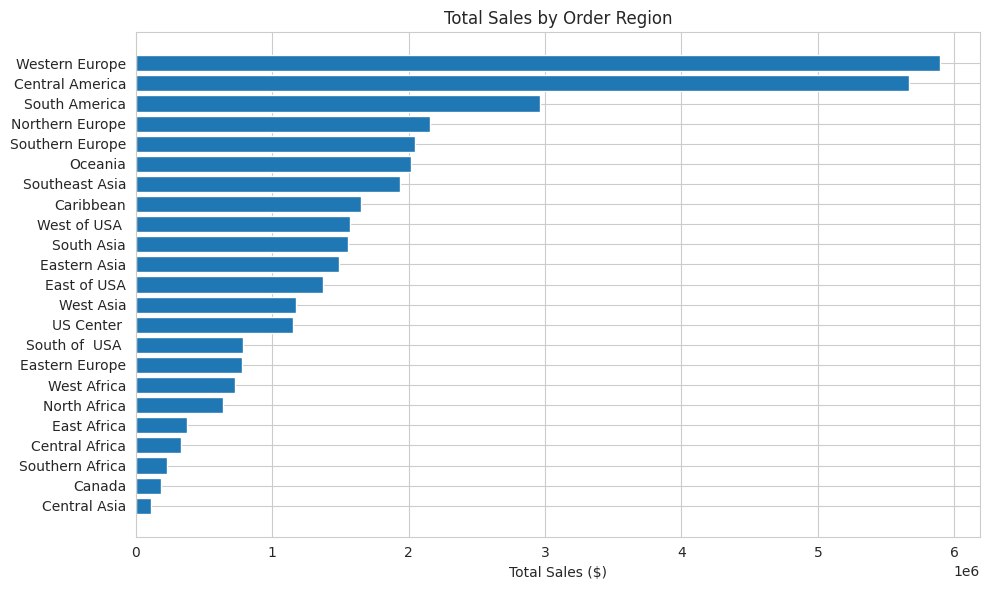

In [15]:
plt.figure(figsize=(10, 6))
plt.barh(region_sales["Order Region"], region_sales["Total_Sales"])
plt.gca().invert_yaxis()
plt.title("Total Sales by Order Region")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.show()

## 8. Category Sales Trend (Monthly)

Monthly sales by category, useful for spotting categories with declining sales over time.

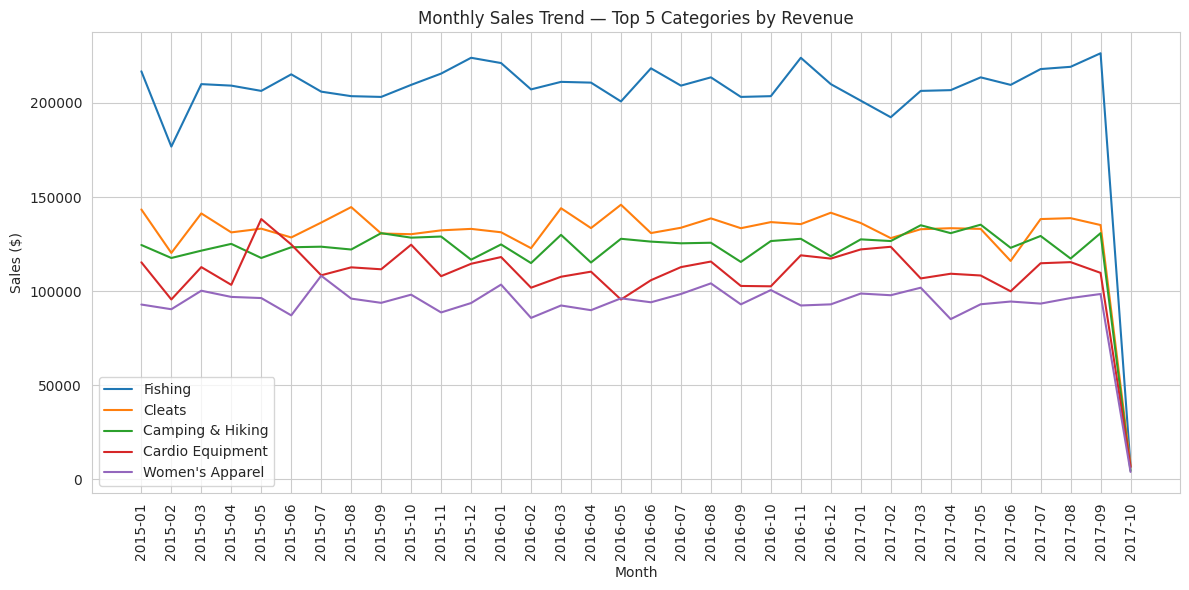

In [16]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])
df["Order_Month"] = df["order date (DateOrders)"].dt.to_period("M").astype(str)

category_monthly_sales = (
    df.groupby(["Category Name", "Order_Month"])["Sales"]
      .sum()
      .round(2)
      .reset_index(name="Monthly_Sales")
)

top5_categories = (
    df.groupby("Category Name")["Sales"].sum().sort_values(ascending=False).head(5).index
)

plt.figure(figsize=(12, 6))
for cat in top5_categories:
    subset = category_monthly_sales[category_monthly_sales["Category Name"] == cat]
    plt.plot(subset["Order_Month"], subset["Monthly_Sales"], label=cat)

plt.title("Monthly Sales Trend — Top 5 Categories by Revenue")
plt.xlabel("Month")
plt.ylabel("Sales ($)")
plt.xticks(rotation=90)
plt.legend()
plt.tight_layout()
plt.show()

## 9. Key Findings & Recommendations

**Data quality:** No duplicate rows. `Product Description` is fully empty (180,519/180,519 missing) and `Order Zipcode` is missing for ~86% of rows — both can likely be dropped or ignored rather than imputed. A handful of customer name/zipcode fields have negligible missingness.

**Revenue:** Total revenue across the dataset is **$36.78M**. Revenue is concentrated at the top: the **Field & Stream Sportsman 16 Gun Fire Safe** alone accounts for ~$6.93M (~19% of total revenue), nearly 1.6x the next-highest product.

**Delivery performance:** On-time rate varies sharply by shipping mode — **Standard Class** is the most reliable (61.9% on-time) despite averaging the longest transit time (4.0 days), while **First Class** has the worst on-time rate (4.7%) even though it's nominally a faster service (2.0-day average). This is a strong signal that First Class delivery promises are not being met and deserves investigation — the "faster" tier is actually the least dependable.

**Cancellations:** Cancellation rates are fairly close across shipping modes (5.2%–6.3%), with **Same Day** highest at 6.3% and **Second Class** lowest at 5.17%. Cancellations are a relatively small share of total order statuses (3,692 of 180,519 rows, ~2%) compared to Pending/Processing/On-Hold states, which make up a much larger share and may be worth their own funnel analysis.

**Regional sales:** **Western Europe** ($5.89M) and **Central America** ($5.67M) are the top two revenue-generating regions, together contributing more than the next four regions combined. Lowest-revenue regions (Central Asia, Southern Africa, Canada) may not be worth the same delivery-network investment as the top regions.

**Recommendations:**
1. Investigate why First Class shipping — the fastest nominal service — has the worst on-time performance; this is likely either a carrier/capacity issue or an unrealistic delivery-time promise.
2. Prioritize inventory and fulfillment reliability for the top revenue products (especially the Fire Safe) given their outsized share of revenue.
3. Since supplier-level data isn't available in this dataset, delivery and cancellation issues can only be diagnosed at the shipping-mode level; adding a supplier/carrier identifier would enable deeper root-cause analysis.
4. Focus regional logistics investment on Western Europe and Central America, which together drive the largest share of revenue.